# Additional Resources

<a target="_blank" href="https://learning.oreilly.com/library/view/ai-agents-the/0642572247775/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="AI Agents Book – Read on O'Reilly"/>
</a>



# Language Agent Tree Search

[Language Agent Tree Search](https://arxiv.org/abs/2310.04406) (LATS), by Zhou, et. al, is a general LLM agent search algorithm that combines reflection/evaluation and search (specifically monte-carlo trees search) to get achieve better overall task performance compared to similar techniques like ReACT, Reflexion, or Tree of Thoughts.

![Graph](https://drive.google.com/uc?export=view&id=1u-zq_WQcuY6FlPB7-VJDCywix45P2W2J)

It has four main steps:

1. Select: pick the best next actions based on the aggregate rewards from step (2). Either respond (if a solution is found or the max search depth is reached) or continue searching.
2. Expand and simulate: select the "best" 5 potential actions to take and execute them in parallel.
3. Reflect + Evaluate: observe the outcomes of these actions and score the decisions based on reflection (and possibly external feedback)
4. Backpropagate: update the scores of the root trajectories based on the outcomes.

**First Framework Incorporating Reasoning, Acting, and Planning to Enhance LM Performance. LATS integrates Monte Carlo Tree Search (MCTS) with LMs to unify reasoning, acting, and planning.**

<br>

__Key Features:__
- LM-based value functions (replaces traditional RL-trained evaluators, leveraging in-context learning)
- Self-reflections for exploration
External feedback for adaptive problem-solving
<br><br>


LATS can be extended to interact with other agents, where each agent:
Represents a different trading strategy or trading signal (e.g., momentum-based, mean reversion, volatility-based).
Outputs possible actions based on its observations and logic.
The tree search can then evaluate these agent-generated strategies to determine the optimal path or combination of strategies.

LATS is highly compatible with reinforcement learning (RL):
Nodes in the tree can represent states in a trading environment.
Branches represent actions, such as going long, short, or hedging positions.

Agents can learn from the results of past searches and adjust their strategies, continuously improving through feedback.

## __LATS__

__Core Concept:__

LATS Framework: Combines Monte Carlo Tree Search (MCTS) with language models (LMs) to enable flexible and adaptive problem-solving for reasoning, acting, and planning tasks.

__Key Features:__

Integrates external feedback and self-reflection for iterative learning and improvement.
Synergizes reasoning and decision-making strategies, expanding ReAct into a search over a combinatorial space of reasoning and acting steps.

__Integration with Language Models:__

Repurposes pretrained LMs as agents, state evaluators, and feedback generators without requiring additional training.
Uses an LM-based value function to guide decision-making by evaluating states and actions in the MCTS framework.

__LM-Powered Value Function:__

LATS introduces a novel value function tailored for language agents:
Self-generated LM score: Evaluates the quality of states and actions directly using the language model.

__Self-consistency score:__

Assesses the reliability of reasoning across multiple trajectories or iterations.
This value function replaces traditional RL-trained evaluators, leveraging in-context learning instead of costly training processes.

__Planning and Search:__

LATS employs MCTS to construct the optimal trajectory from sampled actions, balancing exploration (new paths) and exploitation (promising paths).
Nodes in the decision tree represent states that combine the original input, action sequences, and environmental observations. Uses UCT (Upper Confidence bounds for Trees) to select the most promising states for expansion.

__Advantages:__
Unlike traditional methods (e.g., BFS, RAP), LATS leverages environmental feedback and integrates external observations without relying on pre-trained world models. Enhances reasoning by integrating self-refinement and self-consistency heuristics. Avoids expensive training by utilizing in-context learning for evaluation.

__Applications:__
Suitable for tasks requiring reasoning, planning, and interaction with external environments. Supports iterative refinement and robust decision-making, storing decision trees in long-term memory for further optimization.


__Comparison to Existing Methods:__
Improves upon ReAct, Reflexion, RAP, and ToT by incorporating structured search mechanisms with LM-based value functions and feedback. Overcomes the limitation of LMs failing to self-correct internal reasoning by integrating external input for refinement.


# Dependencies

Install `langgraph` (for the framework), `langchain_openai` (for the LLM), and `langchain` + `tavily-python` (for the search engine).

We will use tavily search as a tool. You can get an API key [here](https://app.tavily.com/sign-in) or replace with a different tool of your choosing.

In [ ]:
# LangGraph >=0.3 removed langgraph.prebuilt.tool_executor; this notebook uses LangChain tools directly.
!pip install -qU "langchain>=0.3" "langgraph>=0.2" langchain_openai langchain_core pydantic
!pip install -qU tavily-python langchain_community python-dotenv


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.7/508.7 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2.12.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━

# Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
import math
import json
from collections import deque, defaultdict
from typing import Any, List, NamedTuple, Optional, Sequence
from typing_extensions import TypedDict

from IPython.display import Image, display

from langchain_openai import ChatOpenAI

from langchain_core.output_parsers.openai_tools import (
    JsonOutputToolsParser,
    PydanticToolsParser,
)
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import chain as as_runnable
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, ToolMessage
from langchain_core.tools import BaseTool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper
from langchain_core.prompt_values import ChatPromptValue
from langchain_core.runnables import RunnableConfig


class ToolInvocation(NamedTuple):
    """Maps a parsed tool call to execution (replaces removed langgraph.prebuilt)."""
    tool: str
    tool_input: dict[str, Any]


class ToolExecutor:
    """Batch-invoke LangChain tools by name (replaces removed langgraph.prebuilt.ToolExecutor)."""

    def __init__(self, tools: Sequence[BaseTool]):
        self._by_name = {t.name: t for t in tools}

    def batch(self, invocations: list[ToolInvocation]) -> list[Any]:
        out: list[Any] = []
        for inv in invocations:
            if inv.tool not in self._by_name:
                raise KeyError(
                    f"Unknown tool {inv.tool!r}. Available: {list(self._by_name)}"
                )
            out.append(self._by_name[inv.tool].invoke(inv.tool_input))
        return out


True

In [ ]:
# API access
#
# Put your keys in a .env file next to this notebook (never paste them into a cell):
#
#   OPENROUTER_API_KEY=sk-or-v1-...
#   TAVILY_API_KEY=tvly-...
#
# OpenRouter keys: https://openrouter.ai/keys
# Tavily keys:     https://app.tavily.com/sign-in

from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(), override=False)

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

# Tavily's wrapper reads this from the environment.
if TAVILY_API_KEY:
    os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY

_missing = [n for n, v in [("OPENROUTER_API_KEY", OPENROUTER_API_KEY),
                           ("TAVILY_API_KEY", TAVILY_API_KEY)] if not v]
if _missing:
    raise RuntimeError(f"Missing {', '.join(_missing)}. Add them to your .env file.")

print("keys loaded")


# Init LLM

In [ ]:
# OpenRouter is OpenAI-compatible, so ChatOpenAI works by swapping the base URL.
# The model slug is the only thing that changes if you want to compare tiers:
#   openai/gpt-5.6-luna      fast and cheap  (default here)
#   openai/gpt-5.6-luna-pro  same model, reasoning.mode=pro
#   openai/gpt-5.6-terra     balanced
#   openai/gpt-5.6-sol       flagship
#
# LATS is expensive by construction: every rollout generates N candidates and
# reflects on each one, so a single run makes dozens of calls. Luna is the right
# tier for that shape of workload.

OPENROUTER_BASE = "https://openrouter.ai/api/v1"
MODEL = os.getenv("LATS_MODEL", "openai/gpt-5.6-luna")

llm = ChatOpenAI(
    model=MODEL,
    base_url=OPENROUTER_BASE,
    api_key=OPENROUTER_API_KEY,
    temperature=1.0,          # candidates must differ from each other
    default_headers={
        "HTTP-Referer": "https://example.internal/lats",
        "X-Title": "LATS advice notebook",
    },
)

print("model:", MODEL)


# Graph State

LATS is based on a (greedy) Monte-Carlo tree search. For each search steps, it picks the node with the highest "upper confidence bound", which is a metric that balances exploitation (highest average reward) and exploration (lowest visits). Starting from that node, it generates N (5 in this case) new candidate actions to take, and adds them to the tree. It stops searching either when it has generated a valid solution OR when it has reached the maximum number of rollouts (search tree depth).

Your LangGraph state will be composed of two items:
1. The root of the search tree
2. The user input

## Monte Carlo Tree Search

__Selection:__ Start from the root node and traverse the tree to select a node based on the Upper Confidence Bound applied to Trees (UCT).

__Expansion:__ If the selected node is not terminal, expand by generating child nodes from possible actions.

__Simulation:__ Run a random simulation from the new node to estimate a value.

__Backpropagation:__ Propagate the simulation results back up the tree, updating node values along the way.

__Reflection:__ When a trajectory fails, use feedback or self-reflection to adjust future decisions, refining the search by avoiding repeated mistakes and improving strategy.

## Reflection

The reflection chain will score agent outputs based on the decision and the tool responses.
We will call this within the other two nodes.

In [ ]:
from pydantic import BaseModel, Field


class Reflection(BaseModel):
    reflections: str = Field(
        description="The critique and reflections on the sufficiency, superfluency, and general quality of the response."
    )
    score: int = Field(
        description="Score from 0-10 on the quality of the candidate response.",
        ge=0,
        le=10,
    )
    found_solution: bool = Field(
        description="Whether the response has fully solved the question or task."
    )

    def as_message(self):
        reasoning_message = f"Reasoning: {self.reflections}\nScore: {self.score}\nFound Solution: {self.found_solution}"
        print(reasoning_message)  # Print reasoning steps
        return HumanMessage(content=reasoning_message)


    @property
    def normalized_score(self) -> float:
        """Return a normalized score between 0 and 1."""
        return self.score / 10.0

    @classmethod
    def from_response(cls, tool_choices, inputs):
        """Initialize Reflection instance directly from parsed tool response."""
        if not tool_choices:
            # The model answered without calling the Reflection tool. Score it as
            # unusable rather than raising, so one bad candidate cannot kill the run.
            return cls(reflections="No reflection returned by the model.",
                       score=0, found_solution=False)
        reflection = tool_choices[0]
        if not isinstance(inputs["candidate"][-1], AIMessage):
            reflection.found_solution = False
        return reflection


# Configure Prompt Template for Reflection
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Reflect and grade the assistant response to the user question below.",
        ),
        ("user", "{input}"),
        MessagesPlaceholder(variable_name="candidate"),
    ]
)

# Reflection Chain Construction
reflection_llm_chain = (
    prompt
    | llm.bind_tools(tools=[Reflection], tool_choice="Reflection").with_config(
        run_name="Reflection"
    )
    | PydanticToolsParser(tools=[Reflection])
)

@as_runnable
def reflection_chain(inputs) -> Reflection:
    tool_choices = reflection_llm_chain.invoke(inputs)
    reflection = Reflection.from_response(tool_choices, inputs)
    print(f"Reflection for input: {inputs['input']}\n"
          f"Critique: {reflection.reflections}\n"
          f"Score: {reflection.score}\n"
          f"Found Solution: {reflection.found_solution}\n")
    return reflection



## Upper Confidence bounds Applied to Trees (UCT)

The value for expansion is selected by the next iteration. The UCT of a child state $s$ is calculated as follows:


$$
\operatorname{UCT}(s)=V(s)+c \sqrt{\frac{\ln N(p)}{N(s)}},
$$

where:
- $V(s)$: Value estimate of node $s$
- N(s): Visit count of node $s$
- N(p): Visit count of parent node
- c: Exploration weight


## Backpropagation in LATS

The return $r$ is used for updating every $V(s)$ along the path with the formula:

$V(s)=\frac{V_{{old}} (s)(N(s)-1)+r}{N(s)},$

where $V_{old}(s)$ is the old value function.


In [ ]:
class Node:
    __slots__ = (
        "messages", "parent", "children", "value", "visits", "reflection", "depth",
        "_is_solved"
    )

    def __init__(
        self,
        messages: List[BaseMessage],
        reflection: 'Reflection',
        parent: Optional["Node"] = None,
    ):
        self.messages = messages
        self.parent = parent
        self.children = []
        self.value = 0
        self.visits = 0
        self.reflection = reflection
        self.depth = parent.depth + 1 if parent is not None else 1
        self._is_solved = reflection.found_solution if reflection else False
        if self._is_solved:
            self._mark_tree_as_solved()
        self.backpropagate(reflection.normalized_score)

    def __repr__(self) -> str:
        return (
            f"<Node value={self.value}, visits={self.visits},"
            f" solution={self.messages} reflection={self.reflection}/>"
        )

    @property
    def is_solved(self):
        return self._is_solved

    @property
    def is_terminal(self):
        return not self.children

    @property
    def best_child(self):
        if not self.children:
            return None
        return max(self.children, key=lambda child: child.upper_confidence_bound())

    @property
    def best_child_score(self):
        if not self.children:
            return None
        return max(self.children, key=lambda child: int(child.is_solved) * child.value)

    @property
    def height(self) -> int:
        if self.children:
            return 1 + max(child.height for child in self.children)
        return 1

    def upper_confidence_bound(self, exploration_weight=1.0):
        if self.parent is None:
            raise ValueError("Cannot obtain UCT from root node")
        if self.visits == 0:
            return self.value
        average_reward = self.value / self.visits
        exploration_term = math.sqrt(math.log(self.parent.visits) / self.visits)
        return average_reward + exploration_weight * exploration_term

    def backpropagate(self, reward: float):
        node = self
        while node:
            node.visits += 1
            node.value = (node.value * (node.visits - 1) + reward) / node.visits
            node = node.parent

    def get_messages(self, include_reflections: bool = True):
        if include_reflections:
            return self.messages + [self.reflection.as_message()]
        return self.messages

    def get_trajectory(self, include_reflections: bool = True) -> List[BaseMessage]:
        messages = []
        node = self
        while node:
            step_messages = node.get_messages(include_reflections=include_reflections)[::-1]
            messages.extend(step_messages)
            print(f"Step at depth {node.depth}:")
            for msg in step_messages:
                print(msg.content)  # Print reasoning at each step
            print("-----------")
            node = node.parent
        return messages[::-1]


    def _get_all_children(self):
        all_nodes = []
        nodes = deque([self])
        while nodes:
            node = nodes.popleft()
            all_nodes.extend(node.children)
            nodes.extend(node.children)
        return all_nodes

    def get_best_solution(self):
        all_nodes = [self] + self._get_all_children()
        best_node = max(
            all_nodes,
            key=lambda node: int(node.is_terminal and node.is_solved) * node.value,
        )
        return best_node

    def _mark_tree_as_solved(self):
        parent = self.parent
        while parent:
            parent._is_solved = True
            parent = parent.parent


#### The graph state itself

The main component is the tree, represented by the root node.

In [ ]:
class TreeState(TypedDict):
    # The full tree
    root: Node
    # The original input
    input: str
    # How many expansions have run. A hard stop, independent of tree shape.
    rollouts: int


# Define Language Agent

Our agent will have three primary LLM-powered processes:
1. Reflect: score the action based on the tool response.
2. Initial response: to create the root node and start the search.
3. Expand: generate 5 candidate "next steps" from the best spot in the current tree

For more "Grounded" tool applications (such as code synthesis), you could integrate code execution into the reflection/reward step. This type of external feedback is very useful (though adds complexity to an already complicated example notebook).

#### Tools

For our example, we will give the language agent a search engine.

In [ ]:
search = TavilySearchAPIWrapper()
tavily_tool = TavilySearchResults(api_wrapper=search, max_results=5)
tools = [tavily_tool]
tool_executor = ToolExecutor(tools=tools)

## Initial Response

We start with a single root node, generated by this first step. It responds to the user input either with a tool invocation or a response.

In [ ]:
prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are an AI assistant.",
        ),
        ("user", "{input}"),
        MessagesPlaceholder(variable_name="messages", optional=True),
    ]
)


initial_answer_chain = prompt_template | llm.bind_tools(tools=tools).with_config(
    run_name="GenerateInitialCandidate"
)


parser = JsonOutputToolsParser(return_id=True)

### Starting Node

We will package up the candidate generation and reflection in a single node of our graph. This is represented by the following function:

In [ ]:
# Define the node we will add to the graph
def generate_initial_response(state: TreeState) -> dict:
    """Generate the initial candidate response."""
    res = initial_answer_chain.invoke({"input": state["input"]})
    parsed = parser.invoke(res)
    tool_responses = tool_executor.batch(
        [ToolInvocation(tool=r["type"], tool_input=r["args"]) for r in parsed]
    )
    output_messages = [res] + [
        ToolMessage(content=json.dumps(resp), tool_call_id=tool_call["id"])
        for resp, tool_call in zip(tool_responses, parsed)
    ]
    reflection = reflection_chain.invoke(
        {"input": state["input"], "candidate": output_messages}
    )
    root = Node(output_messages, reflection=reflection)
    return {
        **state,
        "root": root,
    }

## Candidate Generation

The following code prompts the same LLM to generate N additional candidates to check.

In [ ]:
def select(root: Node) -> Node:
    """MCTS selection: descend from the root to a leaf, following the highest UCT.

    The original version took root.best_child only, which meant every expansion
    happened at depth 2 and the tree never grew past height 3. Because the depth
    stop condition is expressed in terms of tree height, the search could then
    never terminate on depth and would run until LangGraph's recursion limit.
    """
    node = root
    while node.children:
        node = max(node.children, key=lambda child: child.upper_confidence_bound())
    return node


def expand(state: TreeState, config: RunnableConfig) -> dict:
    """Starting from the "best" node in the tree, generate N candidates for the next step."""
    root = state["root"]
    best_candidate: Node = select(root)
    messages = best_candidate.get_trajectory()
    # Generate N candidates from the single child candidate
    new_candidates = expansion_chain.invoke(
        {"input": state["input"], "messages": messages}, config
    )
    parsed = parser.batch(new_candidates)
    flattened = [
        (i, tool_call)
        for i, tool_calls in enumerate(parsed)
        for tool_call in tool_calls
    ]
    tool_responses = tool_executor.batch(
        [
            ToolInvocation(tool=tool_call["type"], tool_input=tool_call["args"])
            for _, tool_call in flattened
        ]
    )
    collected_responses = defaultdict(list)
    for (i, tool_call), resp in zip(flattened, tool_responses):
        collected_responses[i].append(
            ToolMessage(content=json.dumps(resp), tool_call_id=tool_call["id"])
        )
    output_messages = []
    for i, candidate in enumerate(new_candidates):
        output_messages.append([candidate] + collected_responses[i])

    # Reflect on each candidate
    # For tasks with external validation, you can add it here
    reflections = reflection_chain.batch(
        [{"input": state["input"], "candidate": msges} for msges in output_messages],
        config,
    )
    # Grow tree
    child_nodes = [
        Node(cand, parent=best_candidate, reflection=reflection)
        for cand, reflection in zip(output_messages, reflections)
    ]
    best_candidate.children.extend(child_nodes)
    # The tree was extended in place; we only need to record the rollout.
    return {**state, "rollouts": state.get("rollouts", 0) + 1}

In [ ]:
# Centralized Configuration for LATS with MCTS (separate name: RunnableConfig is also called "config" in nodes)
lats_config = {
    "candidate_count": 5,   # N - number of candidates generated per expansion
    "max_depth": 5,         # max tree height before the search stops
    "max_rollouts": 8,      # hard cap on expansions, whatever the tree shape
}

# Every expansion costs N generations plus N reflections, so the worst case is
# roughly max_rollouts * 2N model calls. With the defaults above that is about
# 80 calls for one question. Lower max_rollouts before raising candidate_count.

# Generate Candidates with Centralized Configuration
# Second parameter must be named `config` so LangChain injects RunnableConfig (keyword-only).
#
# Note on `n`: the OpenAI-compatible `n` parameter asks for several completions in
# one request. Not every model or provider honours it, and several of the newer
# reasoning models reject it outright. So we try it once, then fall back to N
# separate calls issued concurrently. Temperature is 1.0, so the separate calls
# still give us genuinely different candidates, which is what the tree search needs.
from concurrent.futures import ThreadPoolExecutor

_N_SUPPORTED = {"value": True}   # flips to False after the first rejection


def _one_candidate(msgs, callbacks, bound_kwargs):
    result = llm.generate(
        [msgs], callbacks=callbacks, run_name="GenerateCandidate", **bound_kwargs
    )
    return result.generations[0][0].message


def generate_candidates(messages: ChatPromptValue, config: RunnableConfig):
    n = lats_config["candidate_count"]
    bound_kwargs = llm.bind_tools(tools=tools).kwargs
    callbacks = config.get("callbacks")
    msgs = messages.to_messages()
    generations = []

    if _N_SUPPORTED["value"]:
        try:
            chat_result = llm.generate(
                [msgs], n=n, callbacks=callbacks,
                run_name="GenerateCandidates", **bound_kwargs,
            )
            generations = [gen.message for gen in chat_result.generations[0]]
            if len(generations) < n:
                # Provider accepted `n` but returned fewer completions than asked.
                print(f"[candidates] provider returned {len(generations)} of {n} for n; "
                      f"topping up with separate calls")
                _N_SUPPORTED["value"] = False
        except Exception as exc:
            print(f"[candidates] n={n} not supported ({type(exc).__name__}); "
                  f"falling back to {n} separate calls")
            _N_SUPPORTED["value"] = False
            generations = []

    missing = n - len(generations)
    if missing > 0:
        with ThreadPoolExecutor(max_workers=min(missing, 5)) as pool:
            futures = [pool.submit(_one_candidate, msgs, callbacks, bound_kwargs)
                       for _ in range(missing)]
            generations.extend(f.result() for f in futures)

    return generations[:n]

# Build the StateGraph for MCTS with Centralized Depth Control
from typing import Literal
from langgraph.graph import END, StateGraph, START

def should_loop(state: TreeState) -> Literal["expand", "__end__"]:
    """Three ways the search ends: solved, too deep, or out of rollouts."""
    root = state["root"]
    if root.is_solved:
        print("[stop] solution found")
        return END
    if root.height > lats_config["max_depth"]:
        print(f"[stop] max depth reached (height {root.height})")
        return END
    if state.get("rollouts", 0) >= lats_config["max_rollouts"]:
        print(f"[stop] rollout budget spent ({state['rollouts']})")
        return END
    return "expand"

# Initialize the StateGraph with Tree Nodes
builder = StateGraph(TreeState)
builder.add_node("start", generate_initial_response)
builder.add_node("expand", expand)
builder.add_edge(START, "start")

# Set conditional edges based on should_loop function
builder.add_conditional_edges("start", should_loop)
builder.add_conditional_edges("expand", should_loop)

# Compile the graph
graph = builder.compile()

# Usage of expansion chain with centralized configuration
expansion_chain = prompt_template | generate_candidates


#### Candidate generation node

We will package the candidate generation and reflection steps in the following "expand" node.
We do all the operations as a batch process to speed up execution.

## Plot Graph

With those two nodes defined, we are ready to define the graph. After each agent step, we have the option of finishing.

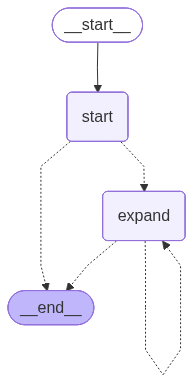

In [ ]:
# draw_mermaid_png() renders via mermaid.ink and needs outbound network.
# Fall back to the Mermaid source if that is unavailable.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print(f"(PNG rendering unavailable: {type(exc).__name__}) -- Mermaid source below\n")
    print(graph.get_graph().draw_mermaid())


#  Run LATS

In [ ]:
def run_lats(graph, question: str):
    """Run the search and return the best trajectory's final message.

    The recursion limit is set from the rollout budget so a runaway search fails
    fast and cheaply instead of hitting LangGraph's default of 25.
    """
    config = {"recursion_limit": lats_config["max_rollouts"] + 5}
    last_root = None

    for step in graph.stream({"input": question, "rollouts": 0}, config):
        step_name, step_state = next(iter(step.items()))
        if isinstance(step_state, dict) and "root" in step_state:
            last_root = step_state["root"]
            print(f"Step: {step_name} | tree height: {last_root.height} "
                  f"| rollouts: {step_state.get('rollouts', 0)}")
        print("---")

    if last_root is None:
        print("No tree was produced.")
        return None

    solution_node = last_root.get_best_solution()
    best_trajectory = solution_node.get_trajectory(include_reflections=True)
    print(f"\nSolved: {last_root.is_solved} | "
          f"best node value: {solution_node.value:.3f}")
    print("\nBest Solution Reasoning Steps:")
    for msg in best_trajectory:
        print(msg.content)
    return best_trajectory[-1].content


In [ ]:
question = """
            Look up the revenue growth and risk factors of Uber and Lyft for 2025,
            which company is performing better? Please use concrete numbers to inform your decision.
            """
best_solution_content = run_lats(graph, question)
if best_solution_content:
    print("Best solution content:", best_solution_content)


Reflection for input: 
            Look up the revenue growth and risk factors of Uber and Lyft for 2025,
            which company is performing better? Please use concrete numbers to inform your decision.
            
Critique: The candidate response was invalid because it attempted to call unavailable search tools and did not answer the user directly. It failed to synthesize concrete 2025 revenue growth and risk factors for Uber and Lyft, and provided no comparative judgment.
Score: 1
Found Solution: False

Step: start
Tree rolled out: 1
---
Reasoning: The candidate response was invalid because it attempted to call unavailable search tools and did not answer the user directly. It failed to synthesize concrete 2025 revenue growth and risk factors for Uber and Lyft, and provided no comparative judgment.
Score: 1
Found Solution: False
Step at depth 1:
Reasoning: The candidate response was invalid because it attempted to call unavailable search tools and did not answer the user directly